# Exercises

## Exercise 1: explore filter parameters
---
In this exercises you will explore how different parameters affect the filtering process.
- Import the data form `data/moving_lfp.pickle` (the file is already on your machine if you run the `download_data()` cell in the main lesson)
- Take a few seconds of the data, and filter them in different frequency bands. Plot the resulting singal.
  Fix the central frequency and play with the width of the band, then try to change the central frequency of the band.
- Change the order of the filter, keeping the frequency band fixed. How does the filtered signal change? How does the computing time change? (You can try to quantify the computing time with the jupyter magic command [`%timeit`](https://docs.python.org/3/library/timeit.html) )
- Comment on what you see

In [2]:
import os

print(os.getcwd())

os.chdir("C:/Users/larsb/Cognitive_neuroscience_RU/neuro-analysis-nongit/neural-data-master/01-local_field_potential")

c:\Users\larsb\Cognitive_neuroscience_RU\neuro-analysis


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import lfp_functions as lf

# sns.set_theme(context='notebook',style='white',font_scale=1.5,
#               rc = {'axes.spines.top':False,'axes.spines.right':False,
#                      'image.cmap':plt.cm.jet})

sns.set_theme(context='notebook',style='white',font_scale=1.5,
               rc = {'axes.spines.top':False,'axes.spines.right':False})
download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40')

with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz


In [4]:
fs = 1000

mask = fs*8

# selecting 8 seconds of the lfp signal
lfp8 = lfp[0:mask]

len(lfp8)

8000

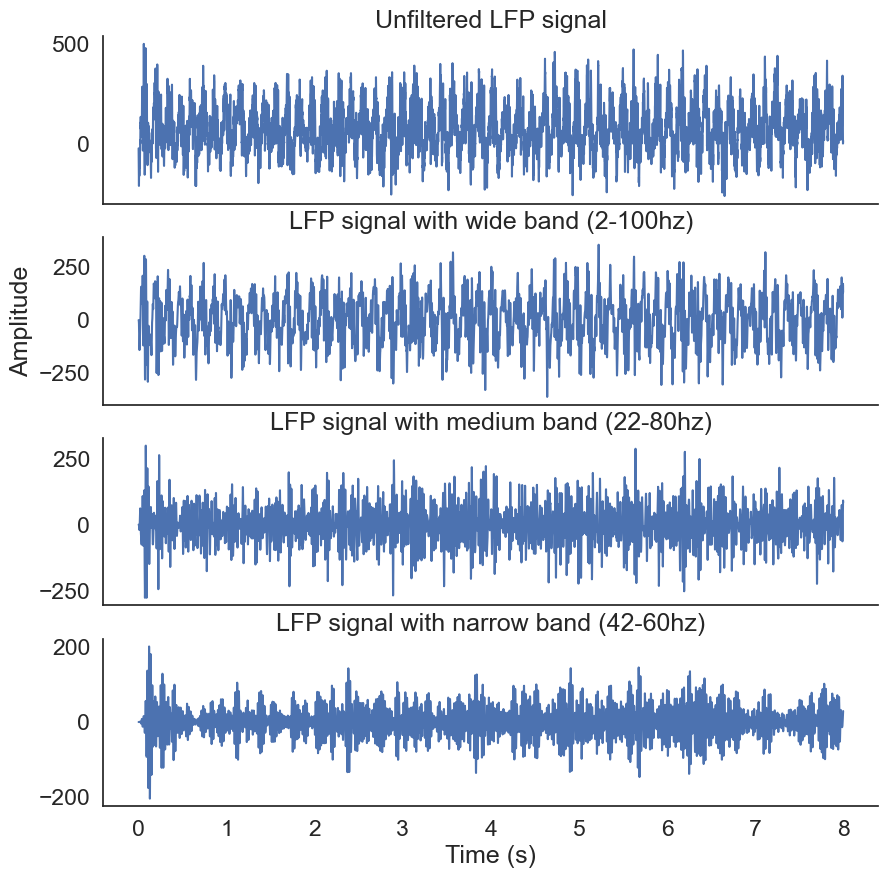

In [5]:
from scipy.signal import butter
from scipy.signal import sosfilt
# this code filteres the LFP signal with different filters centered at the
# same central frequency, but with different widths

# creating a dictionary with different freq band widths, centered at 51hz
bands = {"2-100hz": [2,100],
         "22-80hz": [22,80],
         "42-60hz": [42,60]}
filter_order = 5

lfp_f = [lfp8]
filters = {}

# filter the lfp signals with the different frequency bands
for label, band in bands.items():
    low_f, high_f = band
    filters[label] = butter(filter_order,[low_f, high_f],
                btype='band', 
                output='sos', 
                fs=fs)
    lfp_f.append(sosfilt(filters[label], lfp8))


fig, axs = plt.subplots(4,1, sharex = True)

axs[0].plot(np.linspace(0,8,8000), lfp_f[0])
axs[0].set_title("Unfiltered LFP signal")
axs[1].plot(np.linspace(0,8,8000), lfp_f[1])
axs[1].set_title("LFP signal with wide band (2-100hz)")
axs[2].plot(np.linspace(0,8,8000), lfp_f[2])
axs[2].set_title("LFP signal with medium band (22-80hz)")
axs[3].plot(np.linspace(0,8,8000), lfp_f[3])
axs[3].set_title("LFP signal with narrow band (42-60hz)")

axs[3].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude")
fig.get_tight_layout()
fig.set_size_inches(10, 10)

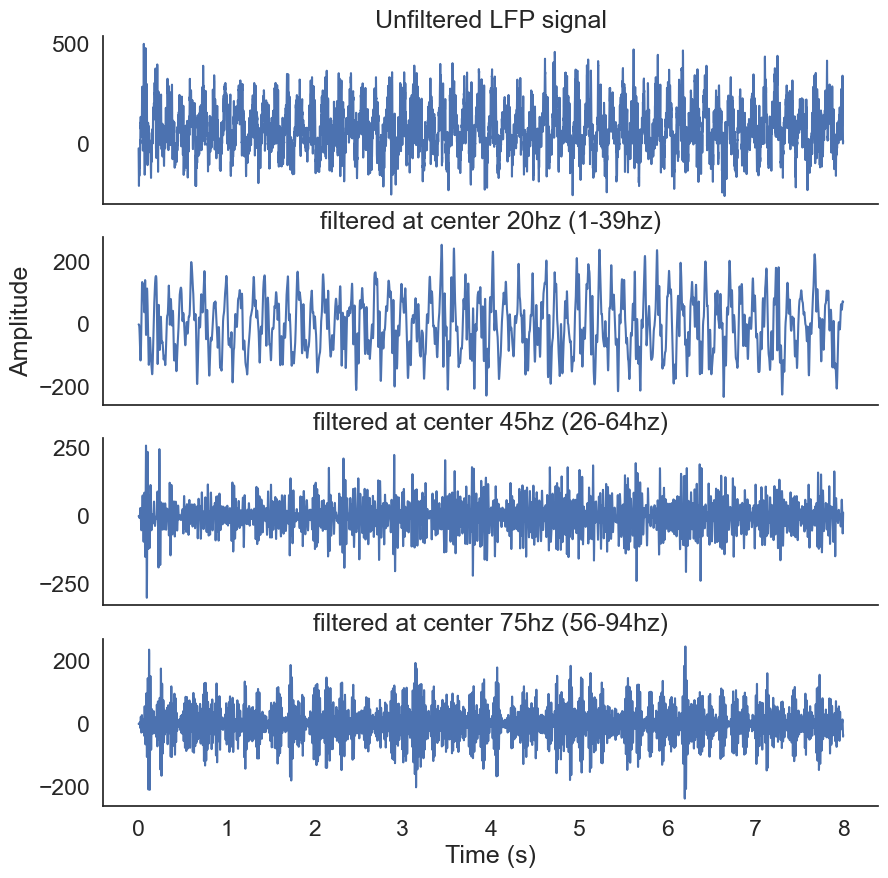

In [6]:
# this code filteres the LFP signal with different filters centered at a different 
# central frequencies, but with the same width
band_center = {"20hz": [1,39],
               "45hz": [26,64],
               "75hz": [56,94]}

lfp_f_c = [lfp8]
filters = {}

# filter the lfp signals with the different frequency bands
for label, band in band_center.items():
    low_f, high_f = band
    filters[label] = butter(filter_order,[low_f, high_f],
                btype='band', 
                output='sos', 
                fs=fs)
    lfp_f_c.append(sosfilt(filters[label], lfp8))

fig, axs = plt.subplots(4,1, sharex = True)

axs[0].plot(np.linspace(0,8,8000), lfp_f_c[0])
axs[0].set_title("Unfiltered LFP signal")
axs[1].plot(np.linspace(0,8,8000), lfp_f_c[1])
axs[1].set_title("filtered at center 20hz (1-39hz)")
axs[2].plot(np.linspace(0,8,8000), lfp_f_c[2])
axs[2].set_title("filtered at center 45hz (26-64hz)")
axs[3].plot(np.linspace(0,8,8000), lfp_f_c[3])
axs[3].set_title("filtered at center 75hz (56-94hz)")

axs[3].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude")
fig.get_tight_layout()
fig.set_size_inches(10, 10)

[ 1  4  7 10]
64.3 μs ± 1.72 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
76.7 μs ± 2.11 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
105 μs ± 6.66 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
142 μs ± 13.3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


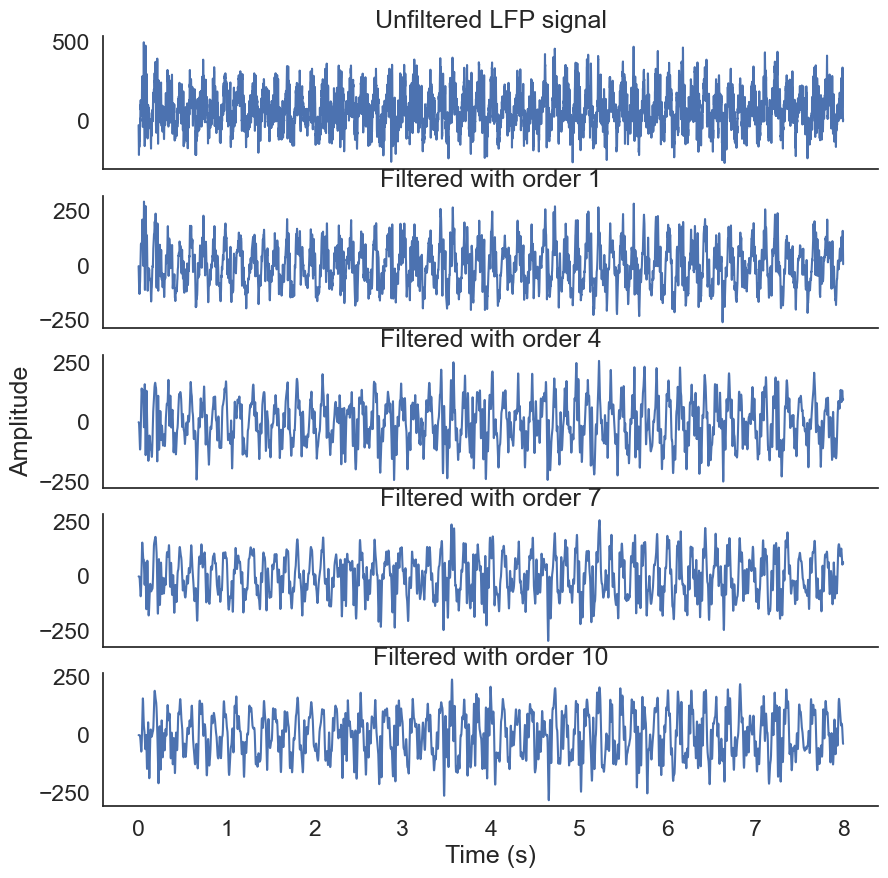

In [7]:
orders = np.linspace(1,10,4, dtype = int)
print(orders)

low_f = 2
high_f = 45

lfp_f_c = [lfp8]
filters = []

# filter the lfp signals with the filter orders with same same band
for order in orders:
    filter = (butter(order,[low_f, high_f],
                btype='band', 
                output='sos', 
                fs=fs))
    
    %timeit sosfilt(filter, lfp8)
    lfp_f_c.append(sosfilt(filter, lfp8))
    
   

fig, axs = plt.subplots(5,1, sharex = True)

axs[0].plot(np.linspace(0,8,8000), lfp_f_c[0])
axs[0].set_title("Unfiltered LFP signal")
axs[1].plot(np.linspace(0,8,8000), lfp_f_c[1])
axs[1].set_title("Filtered with order 1")
axs[2].plot(np.linspace(0,8,8000), lfp_f_c[2])
axs[2].set_title("Filtered with order 4")
axs[3].plot(np.linspace(0,8,8000), lfp_f_c[3])
axs[3].set_title("Filtered with order 7")
axs[4].plot(np.linspace(0,8,8000), lfp_f_c[4])
axs[4].set_title("Filtered with order 10")

axs[4].set_xlabel("Time (s)") 
axs[2].set_ylabel("Amplitude")
fig.get_tight_layout()
fig.set_size_inches(10, 10)

# so order 1 = 52.5us, order 4 is 61.6us, order 7 is 80.1us and order 10 is 112 us
# the higher the order the longer the computing time

# you can especially see the difference between order of 1 and order of 10,
# there seems to be less leakage of higher frequencies in the signal, the filtered
# signal with order 1 resembels the unfiltered signal moreso than with order 10


## Exercise 2: wavelet transform with real wavelets
---
In this exercises you will explore the difference between real and complex wavelets in the continous wavelet transform.
- Import the data form `data/moving_lfp.pickle`
- Select a period of a few seconds of the signal and compute the spectrogram. 
  Try the wavelet transform with wavelet `mexh` (mexican hat),`gaus` (gaussian) and `morl` (morlet). These are all real wavelets.
- What differences do you see with respect to the spectrum computed with the complex Morlet tranform ? Comment on why do you think this might be the case.

Text(80.75, 0.5, 'Freq (hz)')

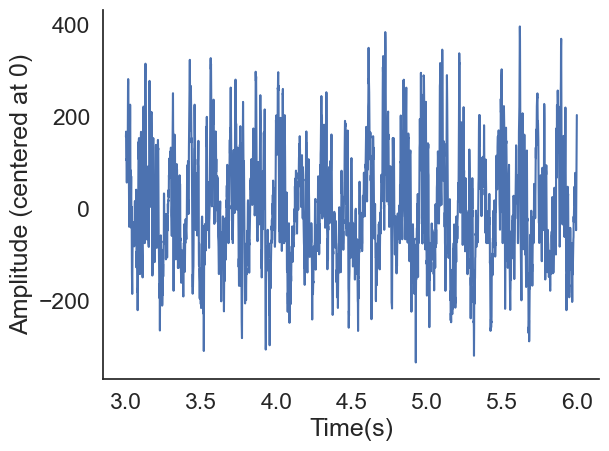

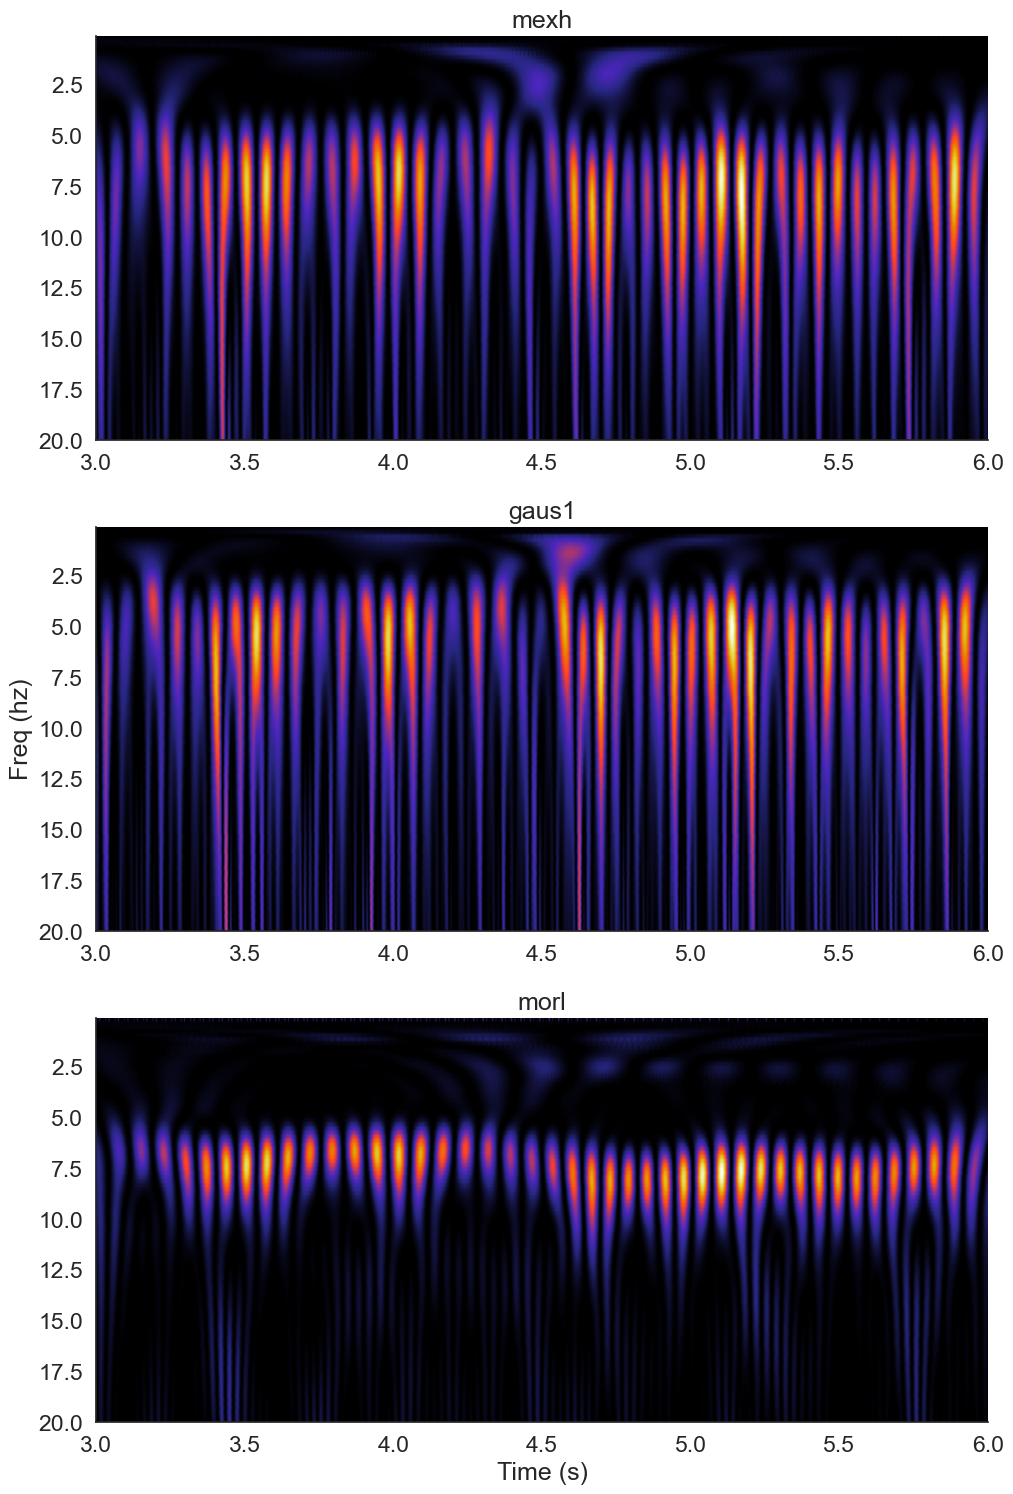

In [8]:
# question for during workgroup/lecture, in the localfieldpotential file,
# why is the plotted envelope such a high frequncy, shoudlt it be in the form of a gaussian
# with a lower freq than the carrier

from pywt import wavelist
from pywt import scale2frequency
from pywt import cwt

start = 3
end = 6

x = np.linspace(start,end,(end-start)*fs)
#plot untransformed LFP signal
sig = lfp[start*fs:end*fs]
sig = sig-np.mean(sig)
plt.plot(x,sig)
plt.xlabel("Time(s)")
plt.ylabel("Amplitude (centered at 0)")

frequencies = np.linspace(0.1,20,100)
wavelet_list = ["mexh", "gaus1", "morl"]

trans_sig = []
scales = []

fig, axs = plt.subplots(3,1,figsize=(10,15))

#loop over the options for the wavelets and plot their spectograms
for i in range(len(wavelet_list)):
    wavelet = wavelet_list[i]
    scales = scale2frequency(wavelet, frequencies/fs)
    cwt_output, _ = cwt(sig, wavelet=wavelet, scales=scales,
                        sampling_period=1.0/fs)
    trans_sig.append(cwt_output)

    axs[i].imshow(abs(trans_sig[i])**2, extent = [start,end,frequencies[-1],
                         frequencies[0]], aspect='auto', cmap='CMRmap')
    axs[i].set_title(wavelet_list[i])

fig.tight_layout()
axs[2].set_xlabel("Time (s)")
axs[1].set_ylabel("Freq (hz)")





Text(0, 0.5, 'Freq (Hz)')

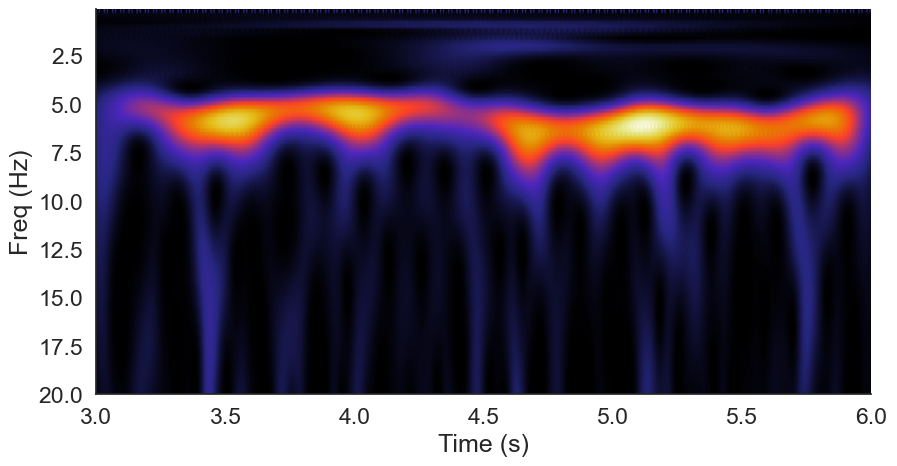

In [9]:
# why b and c 1 in complex morlet in example code

frequencies = np.linspace(0.1,20,100)


#compute spectogram with complex morlet
c_wavelet = "cmor1.0-1.0"

scales = scale2frequency(wavelet, frequencies/fs)
c_cwt_output, _ = cwt(sig, wavelet=c_wavelet, scales=scales,
                     sampling_period=1.0/fs)
plt.figure(figsize=(10,5))
fig  = plt.imshow(abs(c_cwt_output)**2, 
       extent = [start,end,frequencies[-1],
                 frequencies[0]], aspect='auto', cmap='CMRmap') 
plt.xlabel("Time (s)")
plt.ylabel("Freq (Hz)")

# in the real morlet you can see that the power of the frequency oscilates, while
# in the spectogram of the complex morlet, there is a clear smooth power band at 5-7.5hz
# which is the same as in the real morlet. This is because with the real morlet, a cosinus morlet
# is moved over the LFP signal and because the LFP signal oscilates it goes out of fase with
# the real morlet and correlation also goed down (and up again as they go in phase).
# With the complex morelt a correlateion with a cosinus and sinus is calculated and 
# because they are 90 degrees out of phase the wavelet is insensitive for going 
# out of phase, and you see a smooth freq power band

## Exercise 3: REM sleep detection
---
Mammalian sleep is organized in different phases. [Rapid Eye Movement (REM) sleep](https://en.wikipedia.org/wiki/Rapid_eye_movement_sleep) is a well studied phase, with clear markers that make it detectable from LFP data. One of the most used marker is the ratio (or difference) between the oscillatory power in the theta and delta bands in the hippocampus. During REM sleep, the former dominates, in a pattern that resembles active behaviour.  
In this exercise we will use the tools we learned about to detect and inspect the REM and non-REM (nREM) phases of sleep in data recorded from the hippocampus of a sleeping mouse.

- Import the data form `data/sleep_lfp.pickle`
- Compute the instantaneous power in the theta (6-10 Hz) and delta (2-4 Hz) frequency bands, for the whole signal.
- z-score the two power signals (subtract the mean and divide by the standard deviation, you can use `scipy.stats.zscore()`)
- Compute and plot the power difference (`theta_power - delta_power`) for the sleep session.
- Compute the REM (power difference $>0.2$) and nREM (power diffewrence $<0.2$) sleep periods.
- Plot examples of REM vs nREM lfp signals (wideband filtered betw. 1 and 200 Hz to get rid of some of the noise).
- Explore how changing the threshold affects the amount of REM sleep detected.

In [ ]:
#loading data
with open('data/sleep_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

sleep_lfp = lfp_data['lfp']
print(f'Loaded {len(sleep_lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 1816.576 seconds of LFP, sampled at 1000.0 Hz


Text(0.001, 0.55, 'Power (a.u.)')

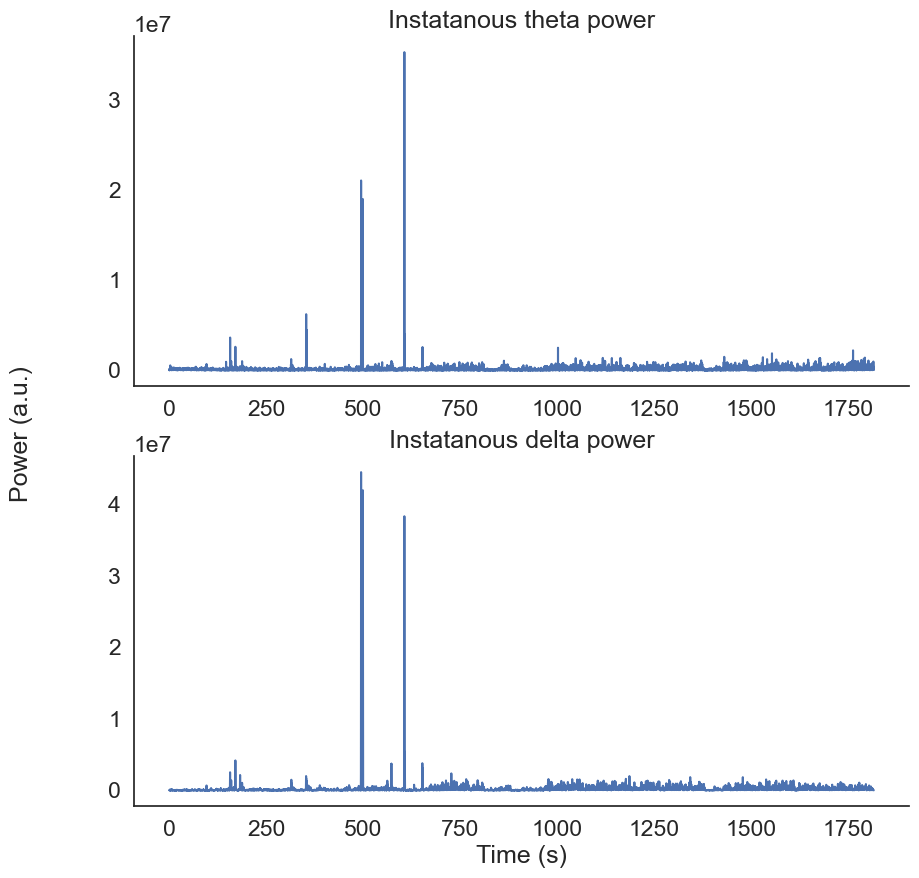

In [ ]:
#computing instantaneous theta and delta power for whole signal
theta_freq = np.linspace(6,10,50)
delta_freq = np.linspace(2,4,50)

sleep_sig = sleep_lfp - np.mean(sleep_lfp)

start = 0
end = len(sleep_sig)/fs

wavelet = 'cmor1.0-1.0'
theta_scales = scale2frequency(wavelet, theta_freq/fs)
delta_scales = scale2frequency(wavelet, delta_freq/fs)

cwtmatr_theta, _ = cwt(sleep_sig, wavelet=wavelet, scales=theta_scales,
                  sampling_period=1.0/fs)
cwtmatr_delta, _ = cwt(sleep_sig, wavelet=wavelet, scales=delta_scales,
                  sampling_period=1.0/fs)

theta_power = np.mean(abs(cwtmatr_theta)**2, axis=0)
delta_power = np.mean(abs(cwtmatr_delta)**2, axis=0)

fig,axs = plt.subplots(2,1, figsize = (10,10))

axs[0].plot(np.linspace(start,end, len(theta_power)), theta_power)
axs[1].plot(np.linspace(start,end, len(delta_power)), delta_power)
axs[1].set_xlabel("Time (s)")
axs[0].set_title("Instantanous theta power")
axs[1].set_title("Instantanous delta power")
fig.text(0.001, 0.55, "Power (a.u.)", rotation=90, va='top')

Text(0.5, 1.0, 'Differences in power of z-scores theta and delta')

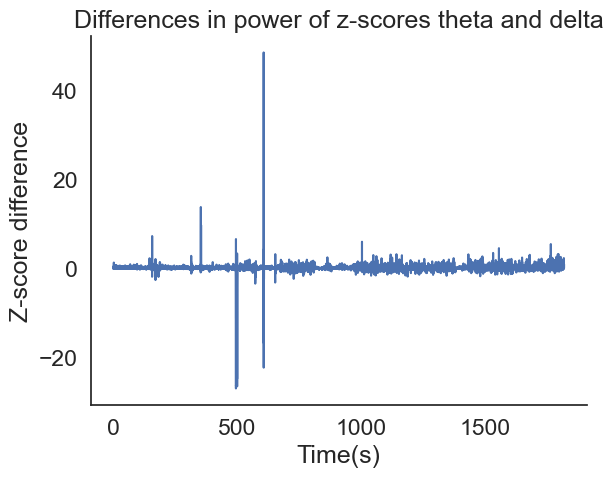

In [12]:
#compute differences of zscored theta and delta power and plot this

import scipy.stats as st

z_theta = st.zscore(theta_power)
z_delta = st.zscore(delta_power)

diff = z_theta-z_delta

plt.plot(np.linspace(start,end,len(diff)), diff)
plt.xlabel("Time(s)")
plt.ylabel("Z-score difference")
plt.title("Differences in power of z-scores theta and delta")


In [ ]:
# compute and periods of rem and non-rem sleep
rem_mask = diff > 0.2
nrem_mask = diff < 0.2

rem_duration=np.count_nonzero(rem_mask==1)/fs
print("REM duration at threshold of 0.2:", rem_duration, "seconds")

nrem_duration=np.count_nonzero(nrem_mask==1)/fs
print("non-REM duration at threshold 0.2:", nrem_duration, "seconds")

rem_mask_higher = diff > 0.3
nrem_mask_higher = diff < 0.3

rem_duration_higher=np.count_nonzero(rem_mask_higher==1)/fs
print("REM duration at threshold of 0.3:", rem_duration_higher, "seconds")

nrem_duration_higher=np.count_nonzero(nrem_mask_higher==1)/fs
print("non-REM duration at threshold 0.3:", nrem_duration_higher, "seconds")

rem_mask_highest = diff > 0.4
nrem_mask_highest = diff < 0.4

rem_duration_highest=np.count_nonzero(rem_mask_highest==1)/fs
print("REM duration at threshold of 0.4:", rem_duration_highest, "seconds")

nrem_duration_highest=np.count_nonzero(nrem_mask_highest==1)/fs
print("non-REM duration at threshold 0.4:", nrem_duration_highest, "seconds")

# The higher you put the threshold, the less sleep is classified as REM sleep

REM duration at threshold of 0.2: 340.66 seconds
non-REM duration at threshold 0.2: 1475.916 seconds
REM duration at threshold of 0.3: 229.347 seconds
non-REM duration at threshold 0.3: 1587.229 seconds
REM duration at threshold of 0.4: 163.505 seconds
non-REM duration at threshold 0.4: 1653.071 seconds


Text(0.5, 0.98, 'sleep LFP signal of 3 longest non-REM sleep segments')

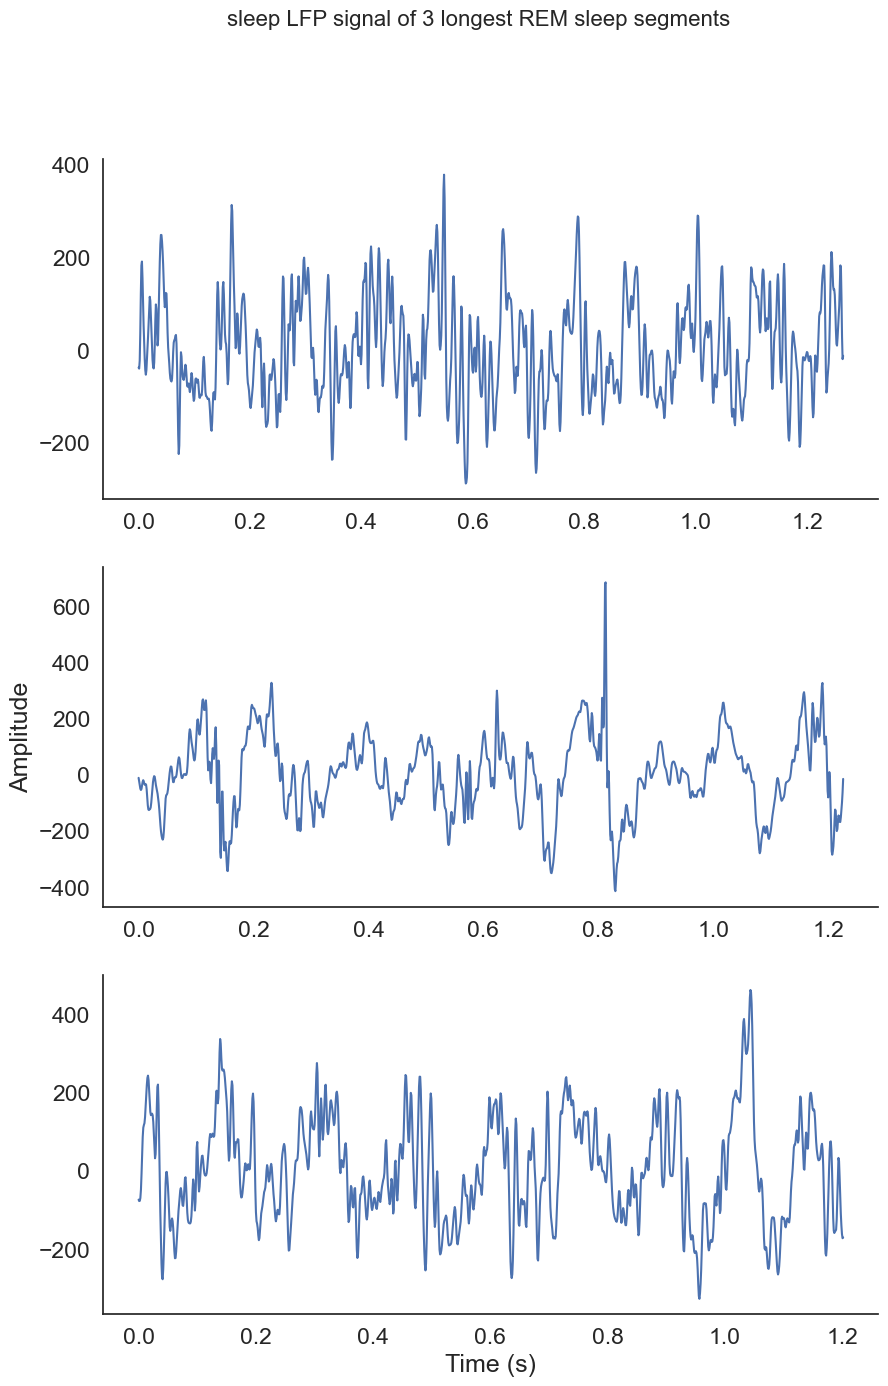

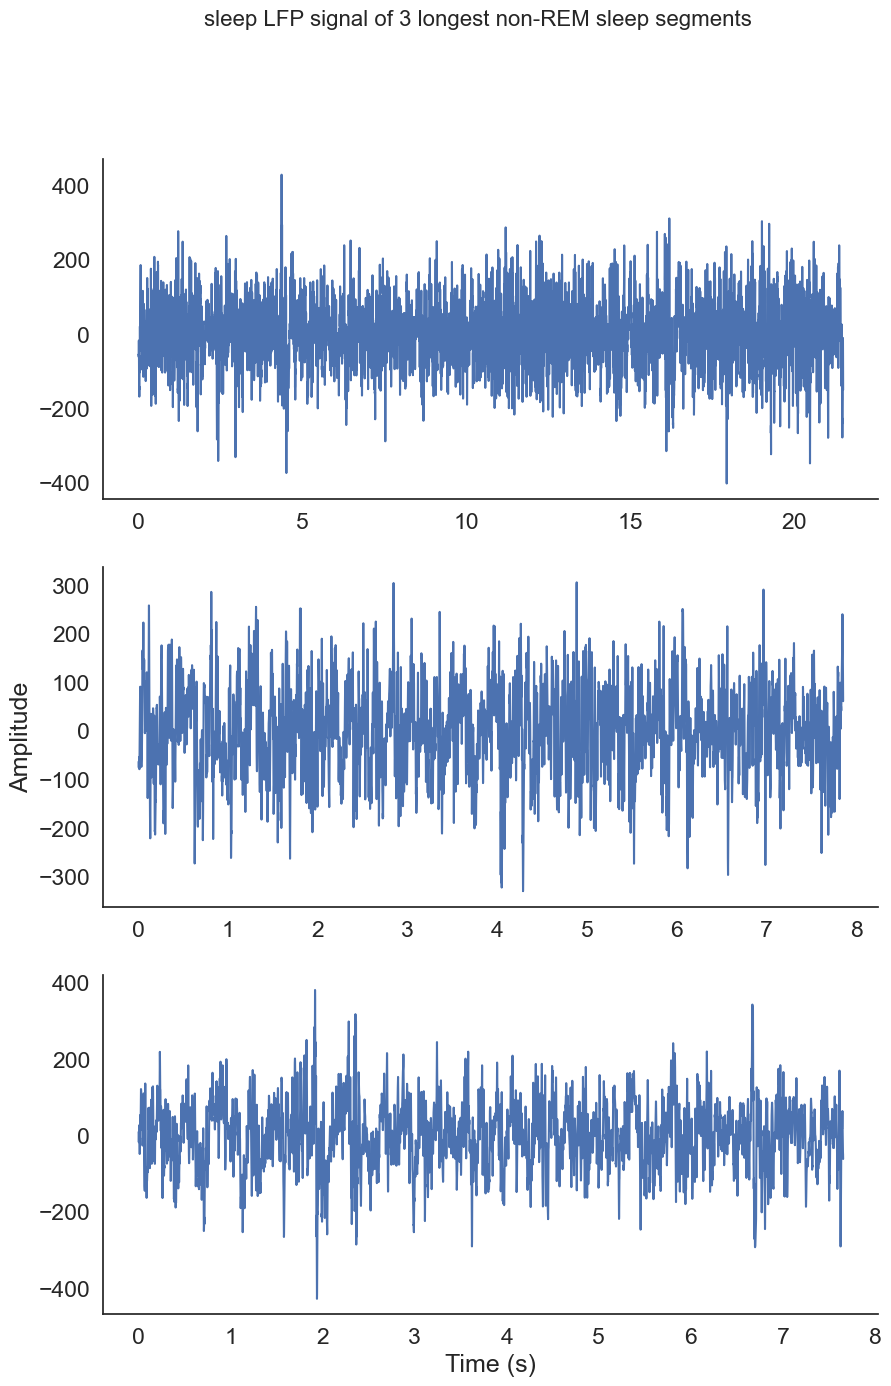

In [32]:

#filter lfp signal between 1 and 200 hz
filter = butter(filter_order,[1, 200],
                btype='band', 
                output='sos', 
                fs=fs)
lfp_sleep_f = sosfilt(filter, sleep_lfp)

#create list of indices of rem and non rem sleep
rem_indices = np.where(rem_mask)[0]
nrem_indices = np.where(nrem_mask)[0]


#make a list with lists with indices that are contiguous periods of rem and non rem sleep
segment = [rem_indices[0]]
total_segments = []

for i in range(1,len(rem_indices)):
    if rem_indices[i] - rem_indices[i-1] == 1:
        segment.append(rem_indices[i])
    else:
        total_segments.append(segment)
        segment = [rem_indices[i]]


segment_nrem = [nrem_indices[0]]
total_segments_nrem = []

for i in range(1,len(nrem_indices)):
    if nrem_indices[i] - nrem_indices[i-1] == 1:
        segment_nrem.append(nrem_indices[i])
    else:
        total_segments_nrem.append(segment_nrem)
        segment_nrem = [nrem_indices[i]]

#extract longest rem and non rem periods
rem_sorted = sorted(total_segments, key = len)
nrem_sorted = sorted(total_segments_nrem, key = len)


fig,axs = plt.subplots(3,1, figsize = (10,15))
for i in range(1,4):
    axs[i-1].plot(np.linspace(0,len(rem_sorted[0-i])/fs, len(rem_sorted[0-i])), lfp_sleep_f[rem_sorted[0-i]])
axs[2].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude")
fig.suptitle("sleep LFP signal of 3 longest REM sleep segments", fontsize=16)

fig,axs = plt.subplots(3,1, figsize = (10,15))
for i in range(1,4):
    axs[i-1].plot(np.linspace(0,len(nrem_sorted[0-i])/fs, len(nrem_sorted[0-i])), lfp_sleep_f[nrem_sorted[0-i]])
    axs[2].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude")
fig.suptitle("sleep LFP signal of 3 longest non-REM sleep segments", fontsize=16)


1226
